# 01 — Análise Exploratória do Fashion-MNIST

O **Fashion-MNIST** (Zalando) é um conjunto de 70.000 imagens em tons de cinza de
**peças de roupa**, cada uma com **28×28 pixels**: 60.000 para treino e 10.000 para
teste. Foi criado como um substituto *drop-in* do MNIST original — mesmo formato,
porém **mais difícil** e representativo de tarefas reais de visão computacional.

São 10 classes: Camiseta/top, Calça, Pulôver, Vestido, Casaco, Sandália, Camisa,
Tênis, Bolsa e Bota.

Objetivo desta análise: **conhecer os dados antes de modelar** — quantos exemplos
por classe, como são as imagens e qual a "cara média" de cada peça.

> Documentação complementar sobre o dataset em `docs/`.

## Identificação e descrição do problema

- **Título:** Classificação de Peças de Roupa com Fashion-MNIST (CNN e baselines clássicos)
- **Integrantes:** Arthur de Azevedo Grazzia e Rafael Rocha da Silva
- **Fonte dos dados:** [Fashion-MNIST](https://github.com/zalandoresearch/fashion-mnist),
  publicado pela Zalando Research; carregado automaticamente via
  `torchvision.datasets.FashionMNIST` (ver `src/utils.py`)
- **Objetivo:** treinar um modelo capaz de reconhecer, a partir da imagem, qual categoria de
  peça de roupa está sendo mostrada (ex.: distinguir uma camisa de um casaco)
- **Atributo-alvo:** a classe da peça de roupa — variável **categórica** com 10 valores
  possíveis (Camiseta/top, Calça, Pulôver, Vestido, Casaco, Sandália, Camisa, Tênis, Bolsa, Bota)
- **Atributos preditivos:** os 784 pixels da imagem (28×28, tons de cinza), tratados como
  atributos numéricos contínuos em [0, 1]
- **Tipo da tarefa:** **classificação multiclasse** (10 classes, mutuamente exclusivas)

In [1]:
# ── Setup — funciona igual no seu PC e no Google Colab ───────────────────────
# Ajuste REPO_URL após publicar o projeto no GitHub (ver README).
import sys, os, subprocess
from pathlib import Path

REPO_URL = "https://github.com/4rth-g/fashion-mnist-fundamentos-ia.git"

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # No Colab não há o repositório: clonamos para ter o código de src/ e as pastas.
    if not Path("fashion-mnist-fundamentos-ia").exists():
        subprocess.run(["git", "clone", REPO_URL], check=True)
    os.chdir("fashion-mnist-fundamentos-ia")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "seaborn"], check=True)

# Torna o pacote src/ importável (local: rodando de notebooks/; Colab: da raiz).
_root = Path.cwd()
_src = _root / "src" if (_root / "src").exists() else _root.parent / "src"
sys.path.insert(0, str(_src))
print("src/ em:", _src)

src/ em: C:\Users\Olfre\OneDrive\Documentos\qonos\UFS\5p\fundamentosDeIA\projetoFinalIA\mnist-fundamentos-ia\src


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from utils import load_fashion_mnist, seed_everything, CLASS_NAMES, FIGURES_DIR

sns.set_theme(style="whitegrid")
seed_everything()

# Carregamos SEM normalizar, para visualizar as imagens na escala natural (0–1).
train_full, test = load_fashion_mnist(normalize=False)
print(f"Treino: {len(train_full)} imagens | Teste: {len(test)} imagens")
print(f"Formato de uma imagem: {train_full[0][0].shape}  (canais × altura × largura)")
print(f"Classes: {CLASS_NAMES}")

Treino: 60000 imagens | Teste: 10000 imagens
Formato de uma imagem: torch.Size([1, 28, 28])  (canais × altura × largura)
Classes: ['Camiseta/top', 'Calça', 'Pulôver', 'Vestido', 'Casaco', 'Sandália', 'Camisa', 'Tênis', 'Bolsa', 'Bota']


## Quantidade de registros, atributos e qualidade dos dados

- **70.000 registros** no total: 60.000 imagens de treino + 10.000 de teste.
- **784 atributos por imagem** (28 × 28 pixels), todos do mesmo tipo: intensidade de cinza,
  contínua em [0, 1] após `ToTensor` (originalmente inteiros de 0 a 255).
- **1 atributo-alvo categórico**, com 10 classes (ver seção anterior).
- Diferente de um dataset tabular heterogêneo (com colunas de tipos distintos, texto, datas
  etc.), aqui todos os atributos são homogêneos — o desafio está na dimensionalidade (784
  atributos) e na estrutura espacial entre eles, não na heterogeneidade de tipos.

Antes de seguir para a exploração visual, verificamos explicitamente três problemas comuns de
qualidade de dados. Como o Fashion-MNIST é um benchmark padrão amplamente utilizado, não
esperamos encontrar problemas — mas confirmamos isso em vez de apenas assumir.

In [3]:
# Amostra para checagem rápida (checar as 70.000 imagens uma a uma seria lento e redundante).
sample_idxs = range(2000)
sample_imgs = np.stack([train_full[i][0].numpy() for i in sample_idxs])

# 1) Valores ausentes: cada imagem é um tensor denso, então "ausência" não é estruturalmente
# possível — mas verificamos explicitamente em vez de assumir.
n_nan = np.isnan(sample_imgs).sum()
print(f"Valores ausentes (NaN) em uma amostra de {len(sample_idxs)} imagens: {n_nan}")

# 2) Duplicatas: imagens idênticas byte-a-byte inflariam a contagem de exemplos "únicos" e,
# em outro contexto, poderiam vazar entre treino e teste.
flat_sample = sample_imgs.reshape(len(sample_imgs), -1)
n_unique = len(np.unique(flat_sample, axis=0))
dup_msg = "nenhuma duplicata" if n_unique == len(flat_sample) else f"{len(flat_sample) - n_unique} duplicata(s)"
print(f"Imagens únicas na amostra: {n_unique}/{len(flat_sample)} ({dup_msg})")

# 3) Inconsistências de rótulo: todo rótulo deve estar no intervalo esperado (0-9).
labels_all = train_full.targets.numpy()
n_invalid = int(((labels_all < 0) | (labels_all > 9)).sum())
print(f"Rótulos fora do intervalo esperado [0, 9] (nas {len(labels_all)} imagens de treino): {n_invalid}")

Valores ausentes (NaN) em uma amostra de 2000 imagens: 0
Imagens únicas na amostra: 2000/2000 (nenhuma duplicata)
Rótulos fora do intervalo esperado [0, 9] (nas 60000 imagens de treino): 0


## Distribuição das classes

Um dataset **balanceado** (classes com frequências parecidas) evita que o modelo
fique enviesado para as peças mais comuns. Vamos conferir.

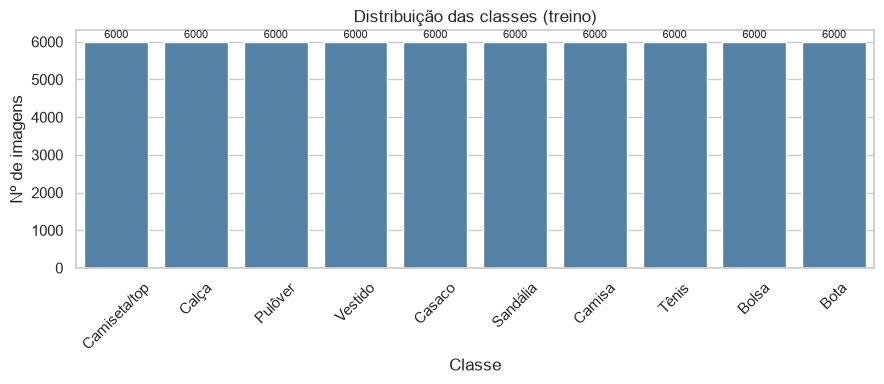

Menos frequente: Camiseta/top (6000) | Mais frequente: Camiseta/top (6000)
Fashion-MNIST é perfeitamente balanceado — 6.000 imagens por classe.


In [4]:
labels = train_full.targets.numpy()
counts = np.bincount(labels)

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(x=CLASS_NAMES, y=counts, ax=ax, color="steelblue")
ax.set(title="Distribuição das classes (treino)", xlabel="Classe", ylabel="Nº de imagens")
ax.tick_params(axis="x", rotation=45)
for i, c in enumerate(counts):
    ax.text(i, c + 100, str(c), ha="center", fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_distribuicao_classes.png", dpi=120)
plt.show()

print(f"Menos frequente: {CLASS_NAMES[counts.argmin()]} ({counts.min()}) | "
      f"Mais frequente: {CLASS_NAMES[counts.argmax()]} ({counts.max()})")
print("Fashion-MNIST é perfeitamente balanceado — 6.000 imagens por classe.")

## Amostras de cada classe

Como cada peça realmente se parece? Mostramos alguns exemplos por classe para
ter noção da **variação de estilos** dentro de cada categoria.

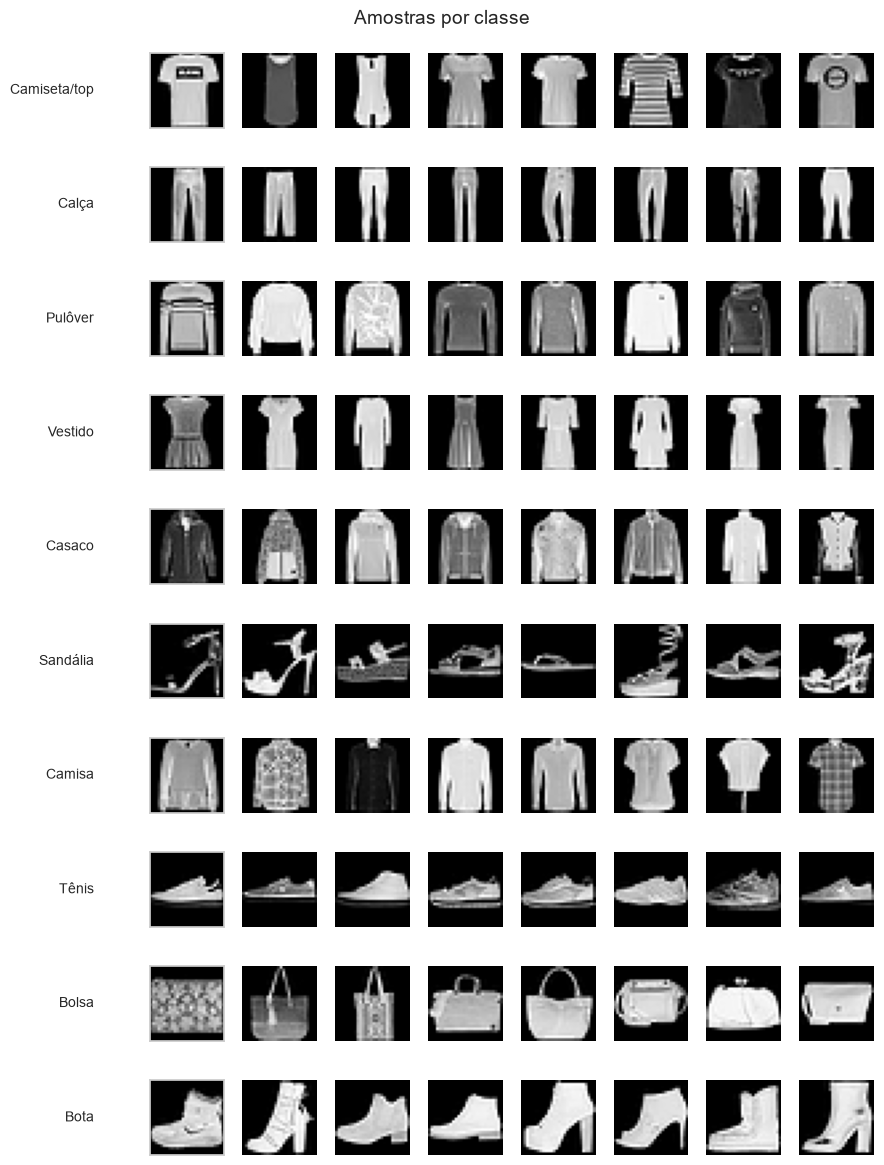

In [5]:
fig, axes = plt.subplots(10, 8, figsize=(9, 12))
for cls in range(10):
    idxs = np.where(labels == cls)[0][:8]
    for col, idx in enumerate(idxs):
        ax = axes[cls, col]
        ax.imshow(train_full[idx][0].squeeze(), cmap="gray")
        ax.axis("off")
    axes[cls, 0].set_ylabel(CLASS_NAMES[cls], rotation=0, labelpad=40,
                            fontsize=10, va="center", ha="right")
    axes[cls, 0].axis("on"); axes[cls, 0].set_xticks([]); axes[cls, 0].set_yticks([])
fig.suptitle("Amostras por classe", fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_amostras_por_classe.png", dpi=120)
plt.show()

## Imagem média de cada classe

Tirando a média de todas as imagens de uma classe, aparece um "protótipo" borrado.
Categorias com formas parecidas (como **Camiseta/top**, **Camisa**, **Pulôver** e
**Casaco**) geram protótipos semelhantes — uma pista de que serão as mais
confundidas pelo modelo depois.

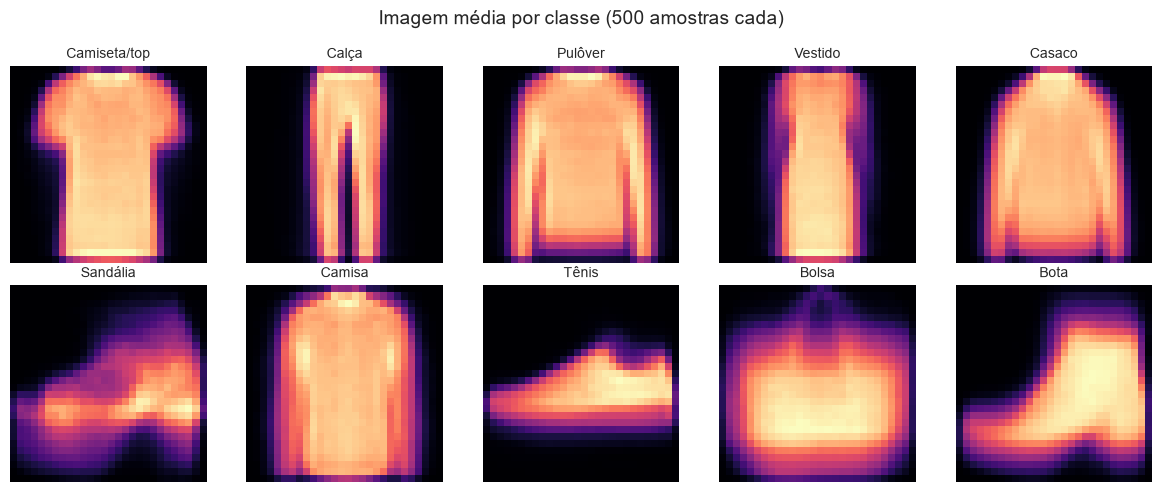

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for cls, ax in enumerate(axes.flat):
    mean_img = np.stack([train_full[i][0].numpy() for i in np.where(labels == cls)[0][:500]]).mean(0)
    ax.imshow(mean_img.squeeze(), cmap="magma")
    ax.set_title(CLASS_NAMES[cls], fontsize=10)
    ax.axis("off")
fig.suptitle("Imagem média por classe (500 amostras cada)", fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_media_por_classe.png", dpi=120)
plt.show()

## Conclusões da EDA

- **70.000 imagens 28×28** em tons de cinza (784 atributos por imagem), 10 classes de peças
  de roupa.
- Dataset **perfeitamente balanceado** (6.000 por classe) → acurácia é uma métrica adequada.
- **Sem valores ausentes, duplicatas ou rótulos inconsistentes** na amostra verificada — um
  dataset de qualidade, como esperado de um benchmark consolidado.
- Há **variação de estilo** dentro de cada categoria; as imagens médias sugerem que os artigos
  "de tronco" (Camiseta/top, Camisa, Pulôver, Casaco) podem ser mais confundidos entre si.
- Próximos passos: `00_baseline.ipynb` treina os modelos clássicos mínimos exigidos
  (SGDClassifier, RandomForestClassifier); `02_cnn.ipynb` treina a CNN, o modelo principal
  do projeto.